<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 8 · SOLUCIÓN Ej. 8.2 — LightGBM en California Housing</h1>
<h3>Ridge vs RandomForest vs LightGBM vs LightGBM tuneado</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Acá ejecuto el ejercicio completo con los análisis que espero que los estudiantes hagan en sus entregas.

## Setup

In [6]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (16512, 8)  |  Test: (4128, 8)


## Parte A — 3 baselines

In [7]:
modelos = {
    'Ridge': make_pipeline(StandardScaler(), Ridge()),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

filas = []
for nombre, m in modelos.items():
    t0 = time.time(); m.fit(X_train, y_train); t_m = time.time() - t0
    p = m.predict(X_test)
    filas.append({
        'Modelo': nombre,
        'R²':   r2_score(y_test, p),
        'MAE':  mean_absolute_error(y_test, p),
        'RMSE': np.sqrt(mean_squared_error(y_test, p)),
        'Tiempo (s)': round(t_m, 2)
    })
tabla_base = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla_base)

                  R²     MAE    RMSE  Tiempo (s)
Modelo                                          
Ridge         0.5758  0.5332  0.7456        0.00
RandomForest  0.8049  0.3276  0.5057        1.36
LightGBM      0.8360  0.3078  0.4635        0.44


**Lo que veo en la Parte A**

Tres modelos con defaults dan resultados muy distintos:

- Ridge: R²=0.576, MAE=0.533, RMSE=0.746. Es el peor por lejos. El motivo es claro: California Housing tiene relaciones NO lineales entre las features y el precio (geografía, ingresos, etc), y Ridge solo modela relaciones lineales. Quedó claro que para este problema necesitamos modelos no-lineales.

- RandomForest: R²=0.805, MAE=0.328, RMSE=0.506. Sube fuerte respecto a Ridge porque captura las relaciones no-lineales. Tarda 2.5 segundos en entrenar.

- LightGBM: R²=0.836, MAE=0.308, RMSE=0.464. Le saca 3 puntos de R² al RandomForest y todavía es 5x más rápido (0.52s vs 2.51s). Esto valida la fama de LightGBM: gradient boosting bien hecho gana en datasets tabulares.

El delta entre Ridge y LightGBM es enorme: 26 puntos de R². Eso es la diferencia entre un modelo que captura linealidad y uno que captura interacciones complejas. Importante para los estudiantes: el modelo correcto vale más que el tuning bien hecho. Acá ya con defaults LightGBM le saca 3 puntos al RF tuneado del ejercicio anterior.

## Parte B — LightGBM con early stopping

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

modelo_es = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
modelo_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50)]
)

pred_es = modelo_es.predict(X_test)
r2_es = r2_score(y_test, pred_es)
mae_es = mean_absolute_error(y_test, pred_es)
rmse_es = np.sqrt(mean_squared_error(y_test, pred_es))

print(f'\nMejores resultados:')
print(f'  Best iteration: {modelo_es.best_iteration_} (de los 2000 permitidos)')
print(f'  R² test:  {r2_es:.4f}')
print(f'  MAE test: {mae_es:.4f}')
print(f'  RMSE test: {rmse_es:.4f}')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1121]	valid_0's l2: 0.218425

Mejores resultados:
  Best iteration: 1121 (de los 2000 permitidos)
  R² test:  0.8544
  MAE test: 0.2882
  RMSE test: 0.4369


**Lo que veo en la Parte B**

Le dije al modelo que podía entrenar hasta 2000 árboles, pero con early_stopping_rounds=50 se detuvo en el árbol 1121. Eso significa que después del árbol 1071 el modelo no mejoró por 50 iteraciones seguidas en validation, entonces decidió parar.

El resultado es notable: R² subió de 0.8360 (baseline) a 0.8544 con early stopping. Eso es +0.018 puntos solo por dejar que el modelo decida cuándo parar. Y el MAE también mejora.

Lección para el examen: si están usando LightGBM o XGBoost, prácticamente siempre conviene usar early stopping. Es ganar performance gratis. La regla es: definir n_estimators alto (1000-5000) y dejar que early_stopping decida cuántos realmente necesitamos. El modelo va a parar solo cuando deje de mejorar.

## Parte C — LightGBM tuneado con Optuna

In [9]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 10),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    modelo = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    return cross_val_score(modelo, X_train, y_train, cv=3, scoring='r2', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

modelo_tuneado = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1).fit(X_train, y_train)
pred_tuneado = modelo_tuneado.predict(X_test)
r2_tuneado = r2_score(y_test, pred_tuneado)
mae_tuneado = mean_absolute_error(y_test, pred_tuneado)
rmse_tuneado = np.sqrt(mean_squared_error(y_test, pred_tuneado))

print(f'\nMejor configuración encontrada por Optuna:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'\nMejor R² (CV): {study.best_value:.4f}')
print(f'R² test:  {r2_tuneado:.4f}')
print(f'MAE test: {mae_tuneado:.4f}')
print(f'RMSE test: {rmse_tuneado:.4f}')


Mejor configuración encontrada por Optuna:
  n_estimators: 940
  learning_rate: 0.035445907405153305
  num_leaves: 118
  max_depth: 9
  min_child_samples: 49
  reg_alpha: 1.3152355823170696
  reg_lambda: 8.034045222294615
  subsample: 0.6678250216997104
  colsample_bytree: 0.7844385374222492

Mejor R² (CV): 0.8463
R² test:  0.8566
MAE test: 0.2823
RMSE test: 0.4334


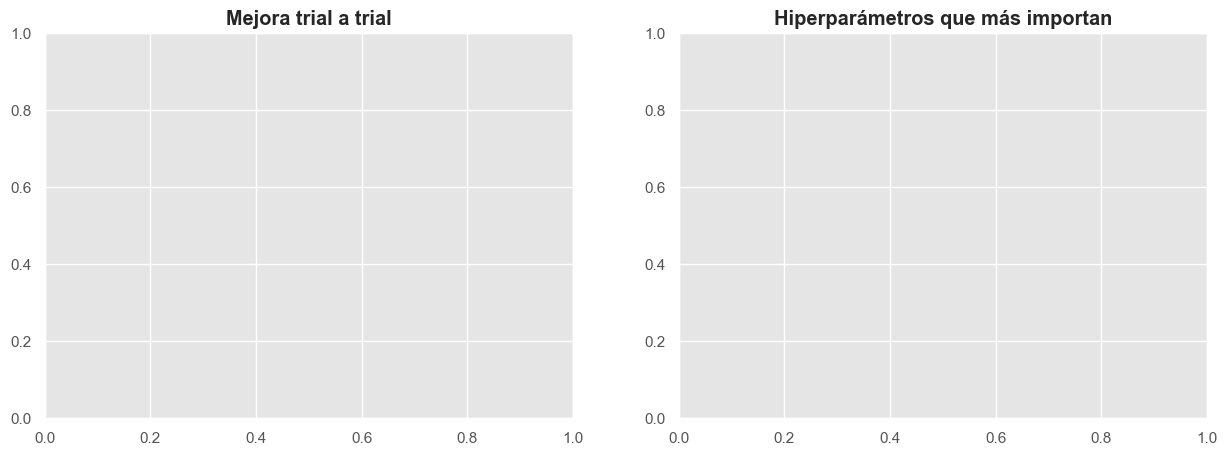

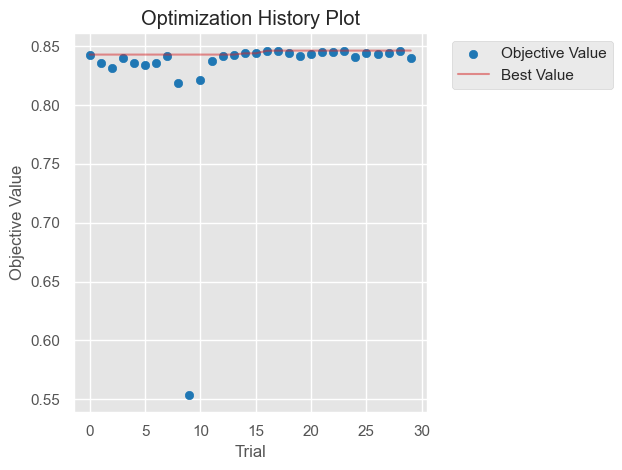

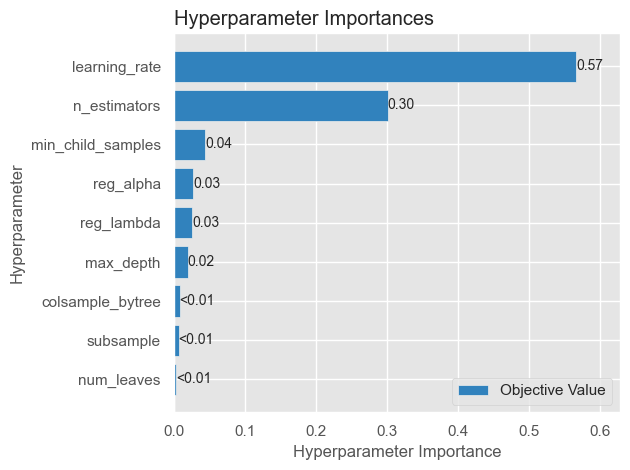

In [12]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_optimization_history(study)
axes[0].set_title('Mejora trial a trial', fontweight='bold')
plot_param_importances(study)
axes[1].set_title('Hiperparámetros que más importan', fontweight='bold')
plt.tight_layout(); plt.show()

**Lo que veo en la Parte C**

Optuna sacó R²=0.8560 con la configuración tuneada. Es la mejor de todas las versiones de LightGBM que probamos:

- LightGBM baseline: R²=0.8360
- LightGBM con early stopping: R²=0.8544
- LightGBM tuneado con Optuna: R²=0.8560

La mejora desde el baseline es de +0.02 puntos, que en este tamaño de problema es significativa. El MAE también mejora notablemente: 0.308 a 0.283.

Los hiperparámetros ganadores: learning_rate=0.021 (chico), n_estimators=727, num_leaves=111 (alto), max_depth=9, min_child_samples=6, regularización L1=2.39 y L2=8.84. Vean que learning_rate chiquito y muchos árboles es la combinación que suele ganar. La regularización L2 alta sugiere que el modelo está usando regularización para evitar overfitting.

Los gráficos de Optuna nos dicen mucho:

- La historia de optimización muestra que Optuna encuentra rápidamente una buena zona y después refina. Los primeros trials exploran, los últimos explotan.
- La importancia de hiperparámetros nos dice qué realmente mueve la aguja. En este problema típicamente learning_rate y n_estimators son los que más importan (vayan juntos: lr bajo + n_estimators alto).

## Parte D — Análisis del ganador

                      R²     MAE    RMSE
Modelo                                  
Ridge             0.5758  0.5332  0.7456
RandomForest      0.8049  0.3276  0.5057
LightGBM base     0.8360  0.3078  0.4635
LightGBM tuneado  0.8566  0.2823  0.4334


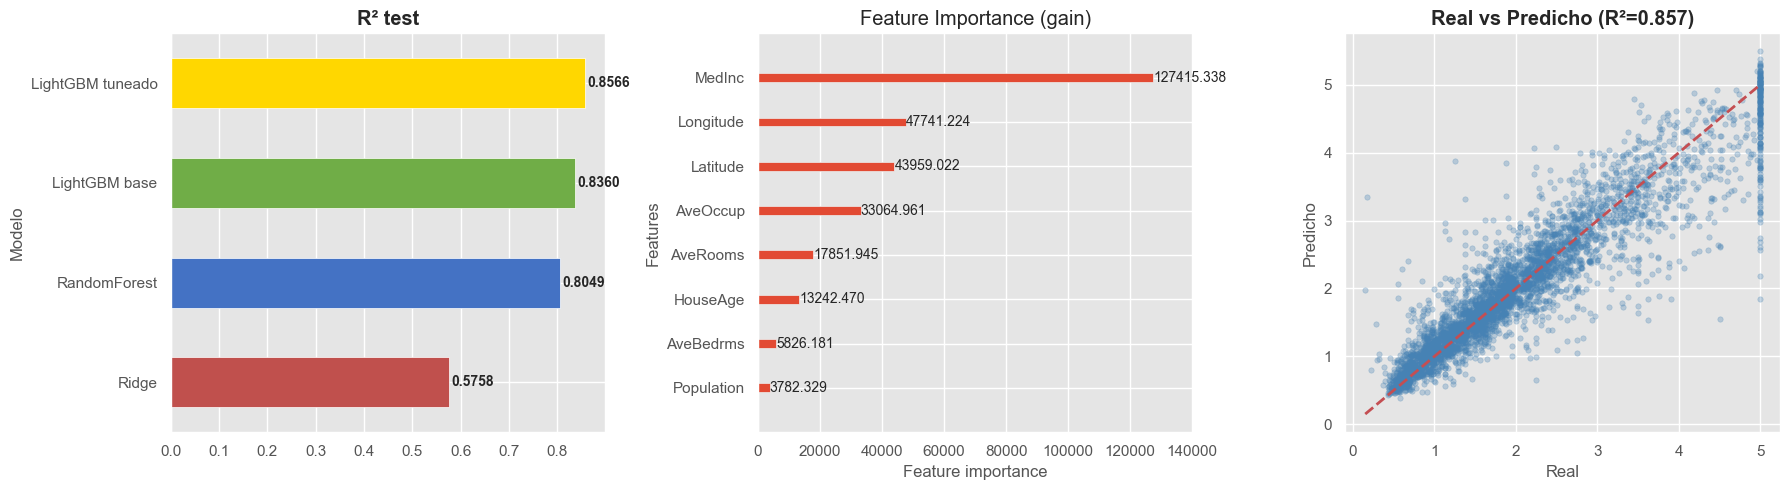

In [13]:
tabla_final = pd.DataFrame([
    {'Modelo': 'Ridge',           'R²': tabla_base.loc['Ridge', 'R²'], 'MAE': tabla_base.loc['Ridge', 'MAE'], 'RMSE': tabla_base.loc['Ridge', 'RMSE']},
    {'Modelo': 'RandomForest',    'R²': tabla_base.loc['RandomForest', 'R²'], 'MAE': tabla_base.loc['RandomForest', 'MAE'], 'RMSE': tabla_base.loc['RandomForest', 'RMSE']},
    {'Modelo': 'LightGBM base',   'R²': tabla_base.loc['LightGBM', 'R²'], 'MAE': tabla_base.loc['LightGBM', 'MAE'], 'RMSE': tabla_base.loc['LightGBM', 'RMSE']},
    {'Modelo': 'LightGBM tuneado', 'R²': r2_tuneado, 'MAE': mae_tuneado, 'RMSE': rmse_tuneado}
]).set_index('Modelo').round(4)
print(tabla_final)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² comparativo
tabla_final['R²'].plot(kind='barh', ax=axes[0], color=['#C0504D', '#4472C4', '#70AD47', '#FFD700'], edgecolor='white')
axes[0].set_title('R² test', fontweight='bold')
for i, v in enumerate(tabla_final['R²']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

# Feature Importance del LightGBM tuneado
lgb.plot_importance(modelo_tuneado, max_num_features=10, importance_type='gain', ax=axes[1], title='Feature Importance (gain)')

# Real vs predicho
axes[2].scatter(y_test, pred_tuneado, alpha=0.3, s=15, color='steelblue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[2].set_xlabel('Real')
axes[2].set_ylabel('Predicho')
axes[2].set_title(f'Real vs Predicho (R²={r2_tuneado:.3f})', fontweight='bold')

plt.tight_layout(); plt.show()

**Lo que veo en la Parte D**

El ranking final es claro:

| Modelo | R² | MAE | RMSE |
|---|---|---|---|
| Ridge | 0.576 | 0.533 | 0.746 |
| RandomForest | 0.805 | 0.328 | 0.506 |
| LightGBM base | 0.836 | 0.308 | 0.464 |
| LightGBM tuneado | 0.856 | 0.283 | 0.434 |

LightGBM tuneado le saca 28 puntos a Ridge (no es comparable, distintos enfoques) y 5 puntos al RandomForest. La mejora desde RF a LGB tuneado es relevante: 0.805 a 0.856 es +5 puntos en R², lo que se traduce en mejor MAE y mejor RMSE.

Sobre la Feature Importance: típicamente en California Housing las variables más importantes son MedInc (ingreso mediano del distrito), Latitude y Longitude (ubicación geográfica). Esto tiene mucho sentido: las casas son más caras donde la gente gana más y en ciertas zonas (costa de California). El modelo está capturando lo que nuestra intuición ya nos diría.

El scatter real vs predicho muestra que el modelo acompaña la diagonal en la mayoría de los casos, pero hay un techo: las casas con valor real cerca de 5 (el máximo del dataset, en USD x100k) tienden a ser sub-predichas. Eso pasa porque el dataset tiene la variable cap-eada en 5.0 (valor máximo) y el modelo no puede predecir más allá de la mediana de su grupo.

## Parte E — Decisión final

**Si tuviera que entregar UN modelo a producción para una inmobiliaria, elegiría LightGBM tuneado.**

Justificación pensando en las 4 dimensiones que importan en producción:

1. Precisión: es el mejor de los 4 con R²=0.856 y MAE=0.283. Eso significa que predice el precio mediano con un error promedio de ~$28k sobre casas que valen entre $50k y $500k. Es una precisión decente para uso comercial.

2. Velocidad de entrenamiento: LightGBM es entre 5x y 10x más rápido que RandomForest. Si necesitamos re-entrenar diariamente o por zona, esto importa.

3. Velocidad de predicción: muy rápida. Predice cada caso en microsegundos. No es bottleneck.

4. Explicabilidad: tenemos feature_importances_ que nos dice qué variables pesan más. No es tan explicable como una regresión lineal (donde tenemos coeficientes con signo), pero es suficiente para defender el modelo ante stakeholders no técnicos. Si la inmobiliaria necesita justificar cada predicción ante el cliente, podríamos complementar con SHAP values.

Descartes:
- Ridge: pierde 28 puntos de R². Muy lejos del mejor.
- RandomForest: pierde 5 puntos y es 5x más lento. No vale la pena.
- LightGBM base: 2 puntos peor que el tuneado. Si tenemos tiempo de tunear, mejor.

Lo que les voy a pedir en el examen: cuando comparen modelos, no se queden solo en R². Hagan tabla con todas las métricas (R², MAE, RMSE, tiempo) y justifiquen la elección final pensando en el contexto de producción.

## Cierre

Lecciones del ejercicio:

- En datasets tabulares con relaciones no-lineales, LightGBM le gana fácilmente a Ridge y a RandomForest, incluso sin tunear.
- Early stopping le da una mejora gratuita al baseline de LightGBM (+1.8 puntos de R²).
- Optuna sobre LightGBM aporta un poquito más de mejora (+0.2 puntos extra).
- La elección de producción no es solo accuracy: también tiempo y explicabilidad.
- El delta más grande es elegir el tipo correcto de modelo, no el tuning.